# Attribute Mining Window Sweep — EDA

Cross-configuration EDA of the attribute-mining pipeline, sourced from
`artifacts/mining/*_symbolic_cscas_gran*_win*/attribute_mining/` -- the windowed mining
grid written by `mine_attribute_schema.py --windowed` (invoked by
`src/thesis/shell-scripts/sweep_attribute_schema.sh`). For every `min_growth_rate x
max_depth` combination (3x3=9), each granularity's timeline is carved into
`n_windows(gran)` chronological windows (10 at gran=0.1, 5 at 0.2, 3 at 0.33, 2 at 0.5,
1 at 1.0 -- 21 windows total across granularities), and each window is mined **in
full**, with no train/test split inside it -- unlike the in-window screening sweep
(`experiments/screening_sweep.py`), which only mines a window's train split. That
gives 9 x 21 = 189 mining runs; `config.yaml` + the run directory name are ground
truth for which `(growth_rate, max_depth, granularity, window)` produced each one --
no log scraping, no assumptions about coverage.

`artifacts/mining/` is a shared root: it also holds runs from the in-window screening
sweep (`screening_cscas_*`) and the temporal-decay experiment (`temporal_decay_cscas_*`),
so this notebook filters strictly to the `symbolic_cscas_gran*_win*` run-name family --
see the loading cell below.


In [17]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

FIGURES_DIR = Path("../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
# Fixed categorical colours, assigned once and reused throughout -- never
# re-derived per plot, so the same growth_rate/max_depth always gets the same
# colour across every figure in this notebook.
GRAN_PALETTE = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377"]
ATTACK_COLOR = "#CC3311"   # warm -> attack-leaning / attack class
BENIGN_COLOR = "#4477AA"   # cool -> benign-leaning / benign class
NEUTRAL_COLOR = "#BBBBBB"


def gran_color_map(grans: list[float]) -> dict[float, str]:
    return {g: GRAN_PALETTE[i % len(GRAN_PALETTE)] for i, g in enumerate(sorted(grans))}


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a 300dpi copy for the thesis alongside the inline notebook display."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved {path}")


def strip_axes(ax) -> None:
    ax.grid(axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def base_feature(token: str) -> str:
    """Strip NOT_/threshold suffix to get the underlying attribute name, e.g.
    'NOT_multi_target' -> 'multi_target',
    'signature_matches_per_day_le_143.7' -> 'signature_matches_per_day'.
    """
    t = token.strip()
    if t.startswith("NOT_"):
        t = t[4:]
    m = re.match(r"^(.*)_(le|gt)_[-0-9.eE]+$", t)
    return m.group(1) if m else t

## 1. Full grid (mining output)

Each of the 189 `(growth_rate, max_depth, granularity, window)` combinations was mined
on that window's **full** alert_groups slice (no held-out split) by
`mine_attribute_schema.py --windowed`, one run per combination under
`artifacts/mining/<timestamp>_symbolic_cscas_gran<g>_win<w>/attribute_mining/`.
`config.yaml` records the exact thresholds used; the directory name records
`granularity` and `win_idx` directly, so there's no need to reverse-engineer them from
data volume (the old approach here, back when mining ran once per data *fraction*
rather than once per window -- see git history if curious).

`mined_attribute_features.csv` in each run dir is the final registered feature set --
Step 1 contrast-set survivors (`mining_type == "contrast_categorical"`) plus Step 2
decision-tree leaves (`mining_type == "decision_tree_rule"`); `contrast_stats_all.csv` /
`contrast_survivors.csv` additionally expose every Step 1 candidate considered vs. the
ones that survived, and why the rest were dropped.


In [19]:
import json

import yaml

MINING_ROOT = Path("../../../artifacts/mining")
SCENARIO = "cscas"

# Matches both the old "symbolic_cscas_gran{g}_win{w}" run names and the
# current sweep_attribute_schema.py ones, which insert the full config
# (gr/md/cw/msl/ac/bc) between the scenario and "gran{g}_win{w}" -- that
# change made run_name unique per (config, window) job again, fixing a
# same-second run-dir collision under the sweep's thread pool (every job
# sharing a window used to write to "symbolic_cscas_gran{g}_win{w}", so
# concurrent configs finishing within the same wall-clock second silently
# clobbered each other's config.yaml/metadata.json -- the root cause of
# the "inconsistent window coverage" assertion below, not something this
# notebook can recover after the fact). `.*` swallows whatever config
# tokens (if any) sit in between; gran/win_idx still only ever appear
# once, right before the end.
RUN_NAME_RE = re.compile(rf"^\d{{8}}_\d{{6}}_symbolic_{SCENARIO}_.*gran([\d.]+)_win(\d+)$")

# CSVs read out of every run_dir, by this notebook, further down --
# mined_attribute_features.csv (1.1+), contrast_stats_all.csv (grid_point_stats
# below), contrast_survivors.csv (1.7). A run_dir with valid config.yaml/
# metadata.json can still have one of these corrupted: the same run-name
# collision that clobbered whole directories (see RUN_NAME_RE's comment
# above) also hit individual files when two threads' df.to_csv() calls
# raced on one path -- each opens in write mode (truncating) and writes from
# its own buffer independently, so their byte streams can interleave into a
# file that belongs to neither config: a line with the wrong field count
# (pandas' C parser raises), or an `itemset` string truncated mid-token
# (ast.literal_eval raises). Validating here, at load time, turns that into
# "row silently excluded" instead of a downstream crash 5 cells later with a
# baffling traceback -- skip_reasons below is printed so a silent exclusion
# is still visible.
def _run_dir_is_valid(mining_dir: Path) -> bool:
    for fname in ("mined_attribute_features.csv", "contrast_stats_all.csv", "contrast_survivors.csv"):
        path = mining_dir / fname
        if not path.exists():
            return False
        try:
            df = pd.read_csv(path)
        except Exception:
            return False
        if "itemset" in df.columns:
            try:
                df["itemset"].apply(ast.literal_eval)
            except Exception:
                return False
    return True


rows = []
skip_reasons = []
for run_dir in sorted(MINING_ROOT.iterdir()):
    m = RUN_NAME_RE.match(run_dir.name)
    if m is None:
        continue
    mining_dir = run_dir / "attribute_mining"
    cfg_path, meta_path = mining_dir / "config.yaml", mining_dir / "metadata.json"
    if not (cfg_path.exists() and meta_path.exists()):
        continue
    if not _run_dir_is_valid(mining_dir):
        skip_reasons.append(run_dir.name)
        continue
    cfg = yaml.safe_load(cfg_path.read_text())
    meta = json.loads(meta_path.read_text())
    rows.append({
        "run_dir": run_dir.name,
        "growth_rate": cfg["contrast"]["min_growth_rate"],
        "max_depth": cfg["tree"]["max_depth"],
        "min_attack_coverage": cfg["contrast"]["min_attack_coverage"],
        "min_benign_coverage": cfg["contrast"]["min_benign_coverage"],
        "class_weight": cfg["tree"]["class_weight"],
        "min_samples_leaf": cfg["tree"]["min_samples_leaf"],
        "gran": float(m.group(1)),
        "win_idx": int(m.group(2)),
        "n_alert_groups": meta["n_alert_groups"],
        "mining_dir": mining_dir,
    })

# All mining runs found, including the class_weight/min_samples_leaf sweep
# points (section 1.10) alongside the original growth_rate x max_depth grid --
# (growth_rate, max_depth, gran, win_idx) alone no longer uniquely identifies a
# run once those two vary too, so the dedup key below includes them.
grid_df_all = pd.DataFrame(rows)

# Grid points get re-mined (new run dir each time) whenever an earlier attempt died
# before recording its schema in the cache index -- e.g. disk-full crashes. Keep the
# latest attempt per grid point; sorted(MINING_ROOT.iterdir()) above already put rows
# in timestamp order, so "latest" is just "last".
grid_df_all = grid_df_all.drop_duplicates(
    subset=[
        "growth_rate", "max_depth", "min_samples_leaf", "class_weight",
        "min_attack_coverage", "min_benign_coverage", "gran", "win_idx",
    ],
    keep="last",
)
grid_df_all = grid_df_all.sort_values(
    ["growth_rate", "max_depth", "class_weight", "min_samples_leaf", "gran", "win_idx"]
).reset_index(drop=True)

# Sections 1.1-1.9 below analyze the original growth_rate x max_depth grid only,
# at the schema's default class_weight/min_samples_leaf -- restricting to those
# rows here (rather than touching every section below) keeps every existing
# groupby/assertion there correct: they assume (growth_rate, max_depth, gran,
# win_idx) uniquely identifies a run, which is only true within this subset.
# Section 1.10 uses grid_df_all directly instead.
grid_df = grid_df_all[
    (grid_df_all["class_weight"] == "balanced")
    & (grid_df_all["min_samples_leaf"] == 20)
    & (grid_df_all["min_attack_coverage"] == 0.05)
    & (grid_df_all["min_benign_coverage"] == 0.05)
    # min_attack_coverage/min_benign_coverage are filtered to a single value
    # above (unlike class_weight/min_samples_leaf) but NOT dropped -- section
    # 1.2's per-row plots (grid_drop_reasons.png) read row["min_attack_coverage"]/
    # row["min_benign_coverage"] straight off grid_df rows to reproduce each
    # config's own contrast-filter thresholds; dropping them here would be a
    # constant-column cleanup that breaks a real downstream consumer.
].drop(columns=["class_weight", "min_samples_leaf"])
grid_df = grid_df.sort_values(["growth_rate", "max_depth", "gran", "win_idx"]).reset_index(drop=True)

GROWTH_RATES = sorted(grid_df["growth_rate"].unique())
MAX_DEPTHS = sorted(grid_df["max_depth"].unique())
GRANULARITIES = sorted(grid_df["gran"].unique())

# Completeness check: every (growth_rate, max_depth) config should cover the exact
# same set of windows for a given granularity -- computed dynamically from what's on
# disk, not a hardcoded total, since window count is a function of granularity alone.
for gran in GRANULARITIES:
    win_sets = (
        grid_df[grid_df.gran == gran]
        .groupby(["growth_rate", "max_depth"])["win_idx"]
        .apply(lambda s: frozenset(s))
    )
    assert win_sets.nunique() == 1, f"gran={gran}: inconsistent window coverage across configs: {win_sets.unique()}"

n_configs = len(GROWTH_RATES) * len(MAX_DEPTHS)
n_windows_total = sum(grid_df[grid_df.gran == g]["win_idx"].nunique() for g in GRANULARITIES)
expected_total = n_configs * n_windows_total
assert len(grid_df) == expected_total, (
    f"expected {n_configs} configs x {n_windows_total} windows-across-granularities "
    f"= {expected_total} grid points, found {len(grid_df)}"
)

if skip_reasons:
    print(f"Skipped {len(skip_reasons)} run_dir(s) with corrupted CSVs (see _run_dir_is_valid): {skip_reasons}")
print(f"Found {len(grid_df)} mining runs (deduped) under {MINING_ROOT.resolve()}")
print(f"growth_rate={GROWTH_RATES}  max_depth={MAX_DEPTHS}  granularity={GRANULARITIES}")
for gran in GRANULARITIES:
    n_win = grid_df[grid_df.gran == gran]["win_idx"].nunique()
    print(f"  gran={gran:g}: {n_win} window(s)")

n_extra = len(grid_df_all) - len(grid_df)
if n_extra:
    print(f"\n+{n_extra} additional class_weight/min_samples_leaf/coverage sweep runs found "
          "(class_weight/min_samples_leaf: section 1.10; coverage: section 1.11)")
else:
    print("\nNo class_weight/min_samples_leaf/coverage sweep runs found yet -- see sections 1.10/1.11.")


Found 192 mining runs (deduped) under /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/mining
growth_rate=[2.0, 3.0, 5.0, 10.0]  max_depth=[1, 3, 5]  granularity=[0.1, 0.25, 0.5]
  gran=0.1: 10 window(s)
  gran=0.25: 4 window(s)
  gran=0.5: 2 window(s)

+384 additional class_weight/min_samples_leaf/coverage sweep runs found (class_weight/min_samples_leaf: section 1.10; coverage: section 1.11)


In [20]:
def grid_point_stats(row: pd.Series) -> dict:
    feats = pd.read_csv(row["mining_dir"] / "mined_attribute_features.csv")
    feats["itemset"] = feats["itemset"].apply(ast.literal_eval)
    contrast = feats[feats["mining_type"] == "contrast_categorical"]
    tree = feats[feats["mining_type"] == "decision_tree_rule"]
    tree_attack = tree[tree["source_label"] == "attack"]

    n_step1_candidates = len(pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv"))

    base_counts: dict[str, int] = {}
    for itemset in tree["itemset"]:
        for tok in itemset:
            feat = base_feature(tok)
            base_counts[feat] = base_counts.get(feat, 0) + 1
    top2_feature_share = (
        sum(sorted(base_counts.values(), reverse=True)[:2]) / len(tree) if base_counts else np.nan
    )

    return {
        # Step 1: candidates generated (every categorical itemset considered) vs.
        # survived the contrast-set filter (n_contrast); Step 2: leaves extracted.
        "n_step1_candidates": n_step1_candidates,
        "n_contrast": len(contrast),
        "n_tree_leaves": len(tree),
        "n_features": len(feats),
        # Every mined feature (Step 1 contrast itemset or Step 2 tree leaf) carries
        # its own source_label -- the class it discriminates *for* -- independent of
        # mining_type, so this is the count that answers "how many attack-leaning vs.
        # benign-leaning features actually went into the schema."
        "n_features_attack": int((feats["source_label"] == "attack").sum()),
        "n_features_benign": int((feats["source_label"] == "benign").sum()),
        "mean_tree_confidence_attack": tree_attack["confidence_attack"].mean() if len(tree_attack) else np.nan,
        "mean_rule_length": tree["itemset"].apply(len).mean() if len(tree) else np.nan,
        "n_distinct_base_features": len(base_counts),
        "top2_feature_share": top2_feature_share,
        # Exact categorical itemsets (Step 1) vs. threshold-stripped base attributes
        # used by tree leaves (Step 2), kept separately for the temporal-stability
        # section below (1.3): Step 1's vocabulary is a small fixed alphabet of
        # categorical values, Step 2's splits are continuous thresholds that shift
        # with the data actually seen, so the two can drift very differently.
        "_contrast_itemset_set": frozenset(t[0] for t in contrast["itemset"]),
        "_tree_base_set": frozenset(base_feature(tok) for itemset in tree["itemset"] for tok in itemset),
    }


grid_df = pd.concat([grid_df, grid_df.apply(grid_point_stats, axis=1).apply(pd.Series)], axis=1)

# Same per-run structural stats, computed for every mining run found (including
# the class_weight/min_samples_leaf sweep points), for section 1.10 below.
grid_df_all = pd.concat(
    [grid_df_all, grid_df_all.apply(grid_point_stats, axis=1).apply(pd.Series)], axis=1
)

GR_COLORS = gran_color_map(GROWTH_RATES)
MD_COLORS = gran_color_map(MAX_DEPTHS)

grid_df.drop(columns=["mining_dir", "_contrast_itemset_set", "_tree_base_set"]).describe().round(3)


,growth_rate,max_depth,min_attack_coverage,min_benign_coverage,gran,win_idx,n_alert_groups,n_step1_candidates,n_contrast,n_tree_leaves,n_features,n_features_attack,n_features_benign,mean_tree_confidence_attack,mean_rule_length,n_distinct_base_features,top2_feature_share
count,192.00,192.000,192.00,192.00,192.000,192.000,192.00,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000
mean,5.00,3.000,0.05,0.05,0.188,3.250,261623.25,922.375,265.828,4.495,270.323,186.443,83.880,0.769,2.253,3.245,1.567
std,3.09,1.637,0.00,0.00,0.134,2.869,187528.78,94.319,74.446,2.274,74.416,64.375,12.172,0.280,0.991,1.973,0.416
min,2.00,1.000,0.05,0.05,0.100,0.000,139532.00,766.000,137.000,2.000,139.000,71.000,66.000,0.200,1.000,1.000,1.000
25%,2.75,1.000,0.05,0.05,0.100,1.000,139532.00,840.750,196.000,2.000,199.000,123.000,75.000,0.500,1.000,1.000,1.000
50%,4.00,3.000,0.05,0.05,0.100,2.500,139532.00,916.500,292.500,4.000,296.000,217.000,79.000,1.000,2.250,3.000,1.750
75%,6.25,5.000,0.05,0.05,0.250,5.250,348831.00,996.500,329.000,6.000,334.000,243.000,95.000,1.000,3.167,4.000,1.833
max,10.00,5.000,0.05,0.05,0.500,9.000,697662.00,1112.000,380.000,11.000,386.000,282.000,114.000,1.000,3.778,8.000,2.143


### 1.1 Parameter interactions: schema size, rule count, feature reuse

Every cell below is a real mined schema, so the interaction between `growth_rate`,
`max_depth`, and `mine_frac` is directly visible: each row is one metric, each column
one `mine_frac`, and each heatmap cell one `(growth_rate, max_depth)` combination.
`top2_feature_share` is the mean number of Step 2 leaves using one of the two
most-reused base attributes -- a rising value means the tree is leaning on a shrinking
core of signals rather than spreading across independent ones.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_step1_step2_interactions.png


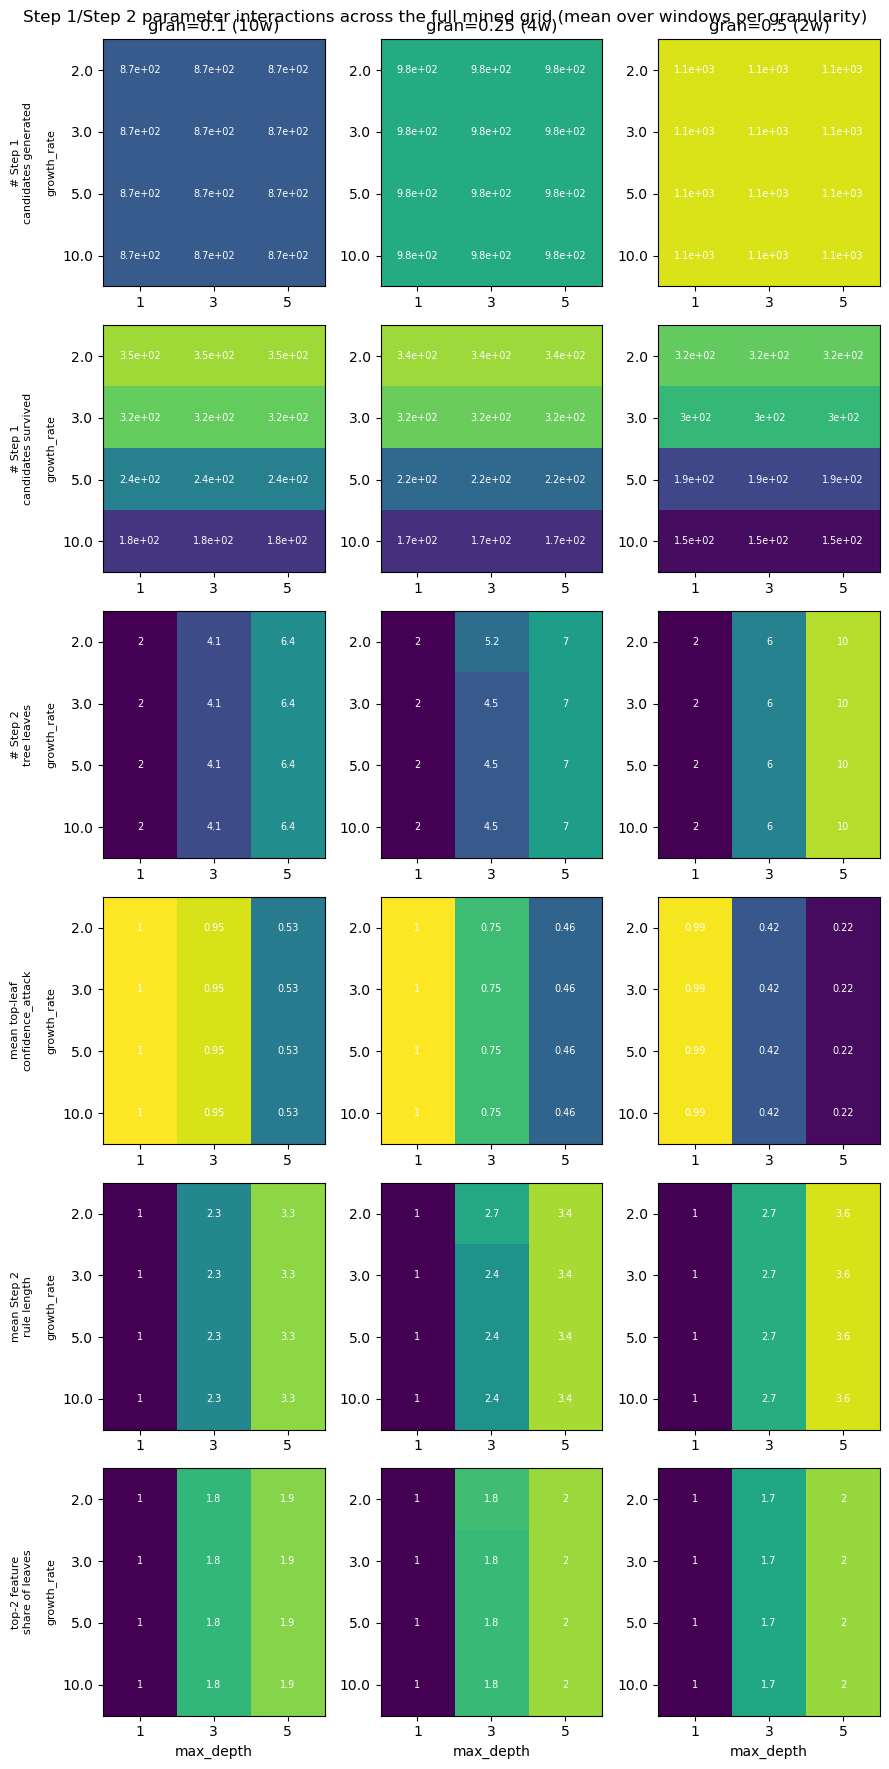

In [21]:
grid_metrics = [
    ("n_step1_candidates", "# Step 1\ncandidates generated"),
    ("n_contrast", "# Step 1\ncandidates survived"),
    ("n_tree_leaves", "# Step 2\ntree leaves"),
    ("mean_tree_confidence_attack", "mean top-leaf\nconfidence_attack"),
    ("mean_rule_length", "mean Step 2\nrule length"),
    ("top2_feature_share", "top-2 feature\nshare of leaves"),
]

fig, axes = plt.subplots(len(grid_metrics), len(GRANULARITIES), figsize=(3.0 * len(GRANULARITIES), 3.0 * len(grid_metrics)))
for row_i, (metric, label) in enumerate(grid_metrics):
    vmin, vmax = grid_df[metric].min(), grid_df[metric].max()
    for col_i, gran in enumerate(GRANULARITIES):
        ax = axes[row_i, col_i]
        # Mean across that granularity's windows -- each cell is one (growth_rate,
        # max_depth) config, averaged over however many windows that granularity has.
        pivot = (
            grid_df[grid_df.gran == gran]
            .groupby(["growth_rate", "max_depth"])[metric].mean()
            .unstack("max_depth")
            .reindex(index=GROWTH_RATES, columns=MAX_DEPTHS)
        )
        ax.imshow(pivot.values, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                ax.text(j, i, f"{pivot.values[i, j]:.2g}", ha="center", va="center", fontsize=7, color="white")
        ax.set_xticks(range(len(MAX_DEPTHS)))
        ax.set_xticklabels(MAX_DEPTHS)
        ax.set_yticks(range(len(GROWTH_RATES)))
        ax.set_yticklabels(GROWTH_RATES)
        n_win = grid_df[grid_df.gran == gran]["win_idx"].nunique()
        if row_i == 0:
            ax.set_title(f"gran={gran:g} ({n_win}w)")
        if col_i == 0:
            ax.set_ylabel(label + "\n\ngrowth_rate", fontsize=8)
        if row_i == len(grid_metrics) - 1:
            ax.set_xlabel("max_depth")

fig.suptitle("Step 1/Step 2 parameter interactions across the full mined grid (mean over windows per granularity)")
fig.tight_layout()
savefig(fig, "grid_step1_step2_interactions.png")
plt.show()


### 1.2 Why Step 1 candidates get dropped

`contrast_stats_all.csv` has every candidate Step 1 considered; `contrast_survivors.csv`
has the ones that made it through. Diffing the two and re-deriving which threshold each
dropped candidate failed (mirroring the filter logic in
`thesis.mining.attribute_contrast_mining`) shows whether tightening `min_growth_rate`
mostly removes genuinely non-discriminative candidates (`growth_rate_too_close_to_1`,
expected and healthy) or starts cutting into candidates that look discriminative but
lack coverage. Shown per granularity at its first window (`win_idx=0`; `max_depth`
doesn't affect Step 1, so one `max_depth` value is representative) -- how the mix
shifts *across windows at the same granularity* is a temporal-stability question,
covered in section 1.3 below instead.


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_drop_reasons.png


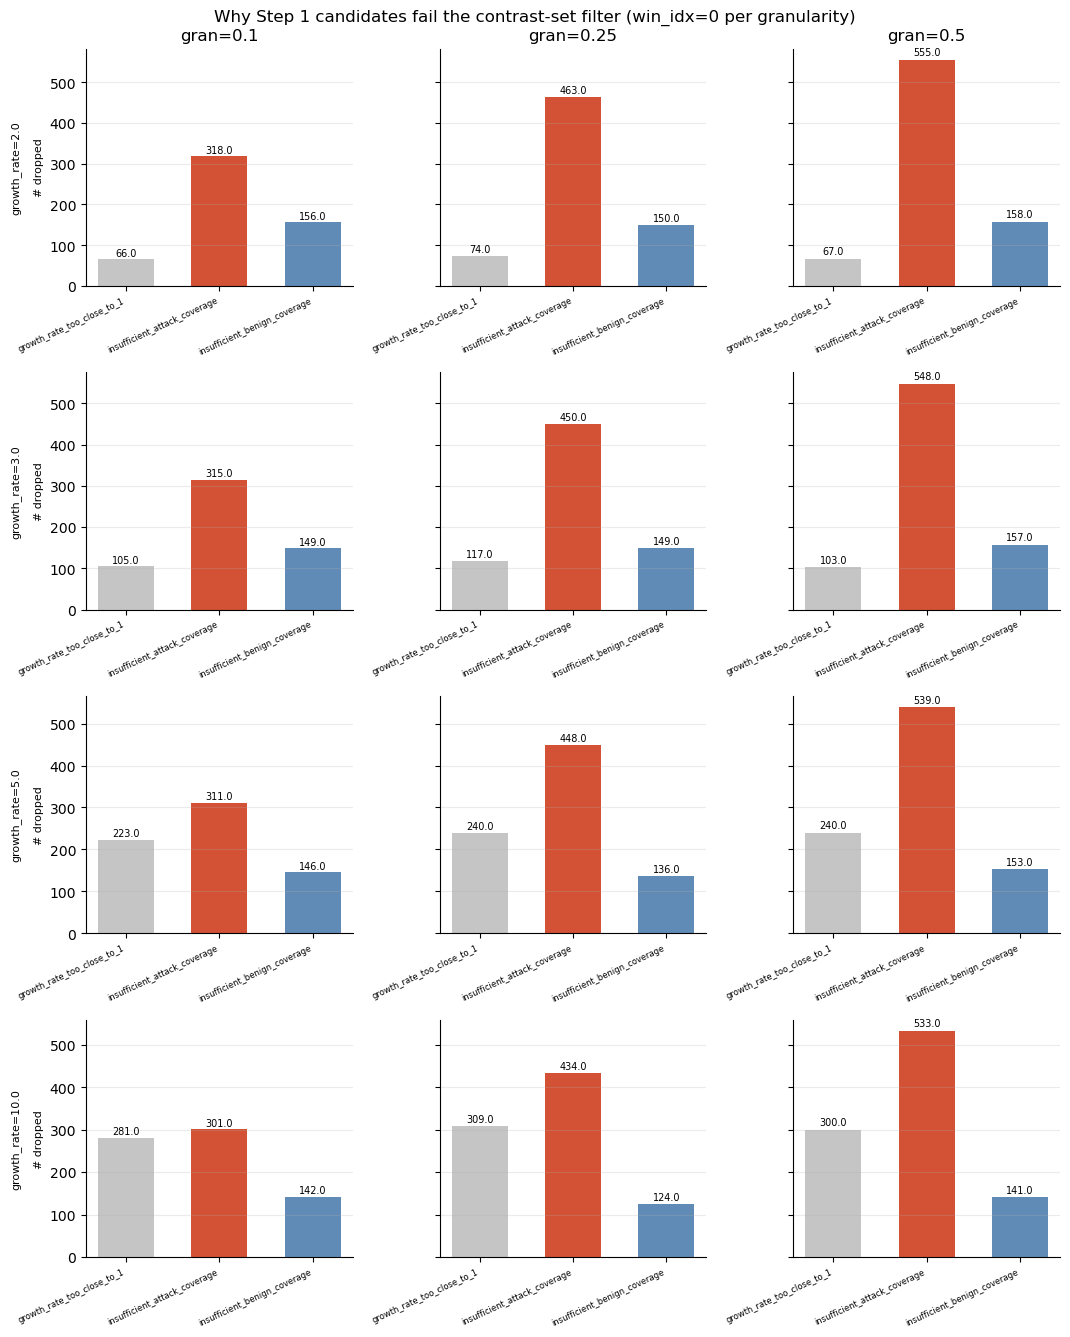

In [22]:
reason_order = ["growth_rate_too_close_to_1", "insufficient_attack_coverage", "insufficient_benign_coverage", "other"]
reason_colors = [NEUTRAL_COLOR, ATTACK_COLOR, BENIGN_COLOR, "#DDCC77"]

fig, axes = plt.subplots(
    len(GROWTH_RATES), len(GRANULARITIES),
    figsize=(3.6 * len(GRANULARITIES), 3.4 * len(GROWTH_RATES)),
    sharey="row",
)
for row_i, gr in enumerate(GROWTH_RATES):
    for col_i, gran in enumerate(GRANULARITIES):
        ax = axes[row_i, col_i]
        row = grid_df[
            (grid_df.growth_rate == gr) & (grid_df.max_depth == MAX_DEPTHS[0])
            & (grid_df.gran == gran) & (grid_df.win_idx == 0)
        ].iloc[0]
        stats_all = pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv")
        survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
        dropped = stats_all[~stats_all["itemset"].isin(set(survivors["itemset"]))].copy()

        inv_threshold = 1.0 / gr if gr > 0 else float("inf")
        attack_leaning = dropped["growth_rate"] >= gr
        benign_leaning = (dropped["confidence_benign"] > 0) & (dropped["growth_rate"] <= inv_threshold)
        conditions = [
            ~(attack_leaning | benign_leaning),
            attack_leaning & (dropped["confidence_attack"] < row["min_attack_coverage"]),
            benign_leaning & (dropped["confidence_benign"] < row["min_benign_coverage"]),
        ]
        dropped["reason"] = np.select(conditions, reason_order[:3], default="other")
        counts = dropped["reason"].value_counts().reindex(reason_order).dropna()

        x = np.arange(len(counts))
        ax.bar(x, counts.values, color=reason_colors[: len(counts)], alpha=0.85, width=0.6)
        for i, v in enumerate(counts.values):
            ax.text(i, v + counts.values.max() * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(counts.index, rotation=25, ha="right", fontsize=6)
        if row_i == 0:
            ax.set_title(f"gran={gran:g}")
        if col_i == 0:
            ax.set_ylabel(f"growth_rate={gr}\n\n# dropped", fontsize=8)
        strip_axes(ax)

fig.suptitle("Why Step 1 candidates fail the contrast-set filter (win_idx=0 per granularity)")
fig.tight_layout()
savefig(fig, "grid_drop_reasons.png")
plt.show()


### 1.3 Temporal stability: how much do mined features drift across windows?

Unlike granularities, windows *within* a granularity are directly comparable -- same
window size, different point in time -- so this is where "does the mined schema stay
the same over time" actually gets answered. For each `(growth_rate, max_depth,
granularity)`, this compares each window's mined feature set to the *previous*
window's (win 0 vs 1, win 1 vs 2, ...) via Jaccard similarity, separately for Step 1
contrast itemsets (exact categorical values) and Step 2 base features
(threshold-stripped, since the numeric thresholds themselves shift with the data even
when the underlying attribute doesn't). A flat line near 1.0 means the mined schema is
stable over time at that granularity; a declining or noisy line means it keeps
reinventing itself window to window. `gran=1.0` has only one window (nothing to
compare it to) and is excluded here.


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_temporal_stability.png


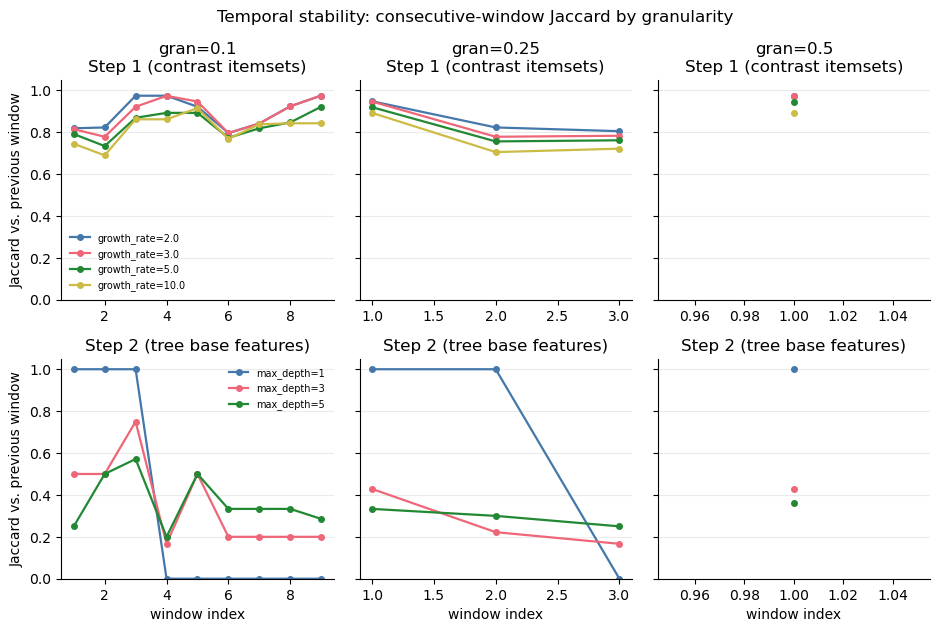

Mean consecutive-window Jaccard by granularity:


,jaccard_contrast,jaccard_tree
gran,,
0.10,0.858,0.353
0.25,0.819,0.447
0.50,0.945,0.597


In [23]:
def jaccard(a: frozenset, b: frozenset) -> float:
    return len(a & b) / len(a | b) if (a or b) else 1.0


stability_rows = []
for (gr, md, gran), sub in grid_df.groupby(["growth_rate", "max_depth", "gran"]):
    sub = sub.sort_values("win_idx")
    prev_contrast, prev_tree, prev_win = None, None, None
    for _, r in sub.iterrows():
        if prev_win is not None:
            stability_rows.append({
                "growth_rate": gr, "max_depth": md, "gran": gran,
                "win_idx": r["win_idx"], "prev_win_idx": prev_win,
                "jaccard_contrast": jaccard(r["_contrast_itemset_set"], prev_contrast),
                "jaccard_tree": jaccard(r["_tree_base_set"], prev_tree),
            })
        prev_contrast, prev_tree, prev_win = r["_contrast_itemset_set"], r["_tree_base_set"], r["win_idx"]

stability_df = pd.DataFrame(stability_rows)
grans_with_multiple_windows = [g for g in GRANULARITIES if grid_df[grid_df.gran == g]["win_idx"].nunique() > 1]

fig, axes = plt.subplots(
    2, len(grans_with_multiple_windows),
    figsize=(3.2 * len(grans_with_multiple_windows), 6.4), sharey="row", squeeze=False,
)
for col_i, gran in enumerate(grans_with_multiple_windows):
    sub = stability_df[stability_df.gran == gran]

    ax = axes[0][col_i]
    for gr in GROWTH_RATES:
        s = sub[(sub.growth_rate == gr) & (sub.max_depth == MAX_DEPTHS[0])].sort_values("win_idx")
        ax.plot(s["win_idx"], s["jaccard_contrast"], marker="o", markersize=4, linewidth=1.6, color=GR_COLORS[gr], label=f"growth_rate={gr}")
    ax.set_title(f"gran={gran:g}\nStep 1 (contrast itemsets)")
    ax.set_ylim(0, 1.05)
    strip_axes(ax)
    if col_i == 0:
        ax.set_ylabel("Jaccard vs. previous window")
        ax.legend(frameon=False, fontsize=7)

    ax = axes[1][col_i]
    for md in MAX_DEPTHS:
        s = sub[(sub.max_depth == md) & (sub.growth_rate == GROWTH_RATES[0])].sort_values("win_idx")
        ax.plot(s["win_idx"], s["jaccard_tree"], marker="o", markersize=4, linewidth=1.6, color=MD_COLORS[md], label=f"max_depth={md}")
    ax.set_title("Step 2 (tree base features)")
    ax.set_xlabel("window index")
    ax.set_ylim(0, 1.05)
    strip_axes(ax)
    if col_i == 0:
        ax.set_ylabel("Jaccard vs. previous window")
        ax.legend(frameon=False, fontsize=7)

fig.suptitle("Temporal stability: consecutive-window Jaccard by granularity")
fig.tight_layout()
savefig(fig, "grid_temporal_stability.png")
plt.show()

print("Mean consecutive-window Jaccard by granularity:")
stability_df.groupby("gran")[["jaccard_contrast", "jaccard_tree"]].mean().round(3)


### 1.4 Mined features by source_label, per window

Every mined feature (Step 1 contrast itemset or Step 2 tree leaf) is tagged with the
class it discriminates *for* (`source_label == "attack"` or `"benign"` ) computed
per grid point in `grid_point_stats` above (`n_features_attack` / `n_features_benign`).
That's a `(growth_rate, max_depth, gran, win_idx)`-level quantity, so it's averaged
across `growth_rate x max_depth` configs to get one bar per window per granularity,
the same aggregation section 1.1 uses in the other direction (average over windows per
config). `metadata.json` only stores each run's total `n_alert_groups`, not the
resulting schema's class split, so this is derived directly from
`mined_attribute_features.csv` rather than the raw data.


  [skip] Loading alert_groups from existing ../../../artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  Loaded 1395324 alert_groups from cache.
  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feature_source_label_by_window.png


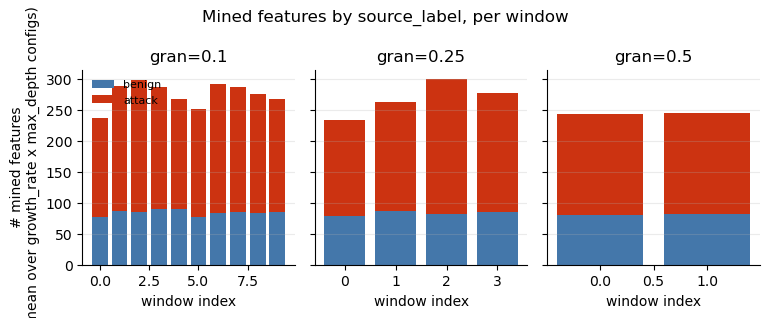

n_features_attack  n_features_benign
gran win_idx                                      
0.10 0                   159.33              77.75
     1                   202.83              86.92
     2                   212.58              85.67
     3                   197.00              90.33
     4                   178.75              90.25
     5                   175.58              77.17
     6                   209.33              83.67
     7                   201.58              85.67
     8                   191.83              84.42
     9                   183.83              84.67
0.25 0                   155.83              79.00
     1                   176.17              87.08
     2                   219.50              81.42
     3                   192.33              85.17
0.50 0                   163.83              80.00
     1                   162.75              82.92

In [24]:
from thesis.pipeline.pipeline import compute_window_bounds, load_or_build_alert_groups
from thesis.experiments._shared import labels_and_mask

_cache_dir = Path("../../../artifacts/cache/cscas/groups/cscas_pregrouped")
_alert_groups = load_or_build_alert_groups(SCENARIO, _cache_dir)
_alert_groups.sort(key=lambda t: t.start_ts or "")

# Raw alert_groups coverage per (gran, win_idx) -- window-level, independent of
# growth_rate/max_depth, kept for the consolidated table in section 1.5.
coverage_rows = []
for gran in GRANULARITIES:
    n_windows = grid_df[grid_df.gran == gran]["win_idx"].nunique()
    for win_idx in range(n_windows):
        start, end, _ = compute_window_bounds(len(_alert_groups), gran, win_idx)
        labels, mask = labels_and_mask(_alert_groups[start:end])
        n_attack = int(np.nansum(labels[mask] == 1.0))
        n_benign = int(np.nansum(labels[mask] == 0.0))
        coverage_rows.append({
            "gran": gran, "win_idx": win_idx,
            "n_alert_groups_window": end - start,
            "n_attack": n_attack, "n_benign": n_benign,
            "attack_frac": n_attack / (n_attack + n_benign) if (n_attack + n_benign) else np.nan,
        })

coverage_df = pd.DataFrame(coverage_rows)
grid_df = grid_df.merge(coverage_df, on=["gran", "win_idx"], how="left")

# Mined feature source_label split per window, averaged over growth_rate x max_depth
# configs sharing that (gran, win_idx) -- this is what actually gets plotted below.
feat_label_by_window = (
    grid_df.groupby(["gran", "win_idx"])[["n_features_attack", "n_features_benign"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(2.6 * len(GRANULARITIES), 3.2), sharey=True)
for ax, gran in zip(axes, GRANULARITIES):
    sub = feat_label_by_window[feat_label_by_window.gran == gran].sort_values("win_idx")
    ax.bar(sub["win_idx"], sub["n_features_benign"], color=BENIGN_COLOR, label="benign")
    ax.bar(sub["win_idx"], sub["n_features_attack"], bottom=sub["n_features_benign"], color=ATTACK_COLOR, label="attack")
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("window index")
    strip_axes(ax)
axes[0].set_ylabel("# mined features\n(mean over growth_rate x max_depth configs)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Mined features by source_label, per window")
fig.tight_layout()
savefig(fig, "grid_feature_source_label_by_window.png")
plt.show()

feat_label_by_window.set_index(["gran", "win_idx"]).round(2)


### 1.5 Consolidated grid table

All 189 combinations, for pulling exact numbers into the thesis text or calling
`.to_latex()` directly.


In [25]:
grid_summary_table = grid_df.drop(columns=["mining_dir", "_contrast_itemset_set", "_tree_base_set"]).set_index(
    ["growth_rate", "max_depth", "gran", "win_idx"]
)
grid_summary_table


run_dir  min_attack_coverage  min_benign_coverage  n_alert_groups  n_step1_candidates  n_contrast  n_tree_leaves  \
growth_rate max_depth gran win_idx                                                                                                                                                               
2.0         1         0.10 0        20260712_112723_symbolic_cscas_gr2.0_md1_cwbal...                 0.05                 0.05          139532                 861         321              2   
                           1        20260712_112736_symbolic_cscas_gr2.0_md1_cwbal...                 0.05                 0.05          139532                 841         380              2   
                           2        20260712_112801_symbolic_cscas_gr2.0_md1_cwbal...                 0.05                 0.05          139532                 911         362              2   
                           3              20260711_181641_symbolic_cscas_gran0.1_win3                 0.05                 0.05          139532                 922         358              2   
                           4        20260712_112815_symbolic_cscas_gr2.0_md1_cwbal...                 0.05                 0.05          139532                 943         360              2   
...                                                                               ...                  ...                  ...             ...                 ...         ...            ...   
10.0        5         0.25 1             20260712_015255_symbolic_cscas_gran0.25_win1                 0.05                 0.05          348831                1018         154              8   
                           2             20260712_021326_symbolic_cscas_gran0.25_win2                 0.05                 0.05          348831                 899         206              7   
                           3             20260712_023452_symbolic_cscas_gran0.25_win3                 0.05                 0.05          348831                 994         182              6   
                      0.50 0              20260712_030505_symbolic_cscas_gran0.5_win0                 0.05                 0.05          697662                1112         138              9   
                           1              20260712_035947_symbolic_cscas_gran0.5_win1                 0.05                 0.05          697662                1074         153             11   

                                    n_features  n_features_attack  n_features_benign  mean_tree_confidence_attack  mean_rule_length  n_distinct_base_features  top2_feature_share  \
growth_rate max_depth gran win_idx                                                                                                                                                  
2.0         1         0.10 0               323                233                 90                     1.000000          1.000000                         1            1.000000   
                           1               382                272                110                     1.000000          1.000000                         1            1.000000   
                           2               364                257                107                     1.000000          1.000000                         1            1.000000   
                           3               360                253                107                     1.000000          1.000000                         1            1.000000   
                           4               362                252                110                     1.000000          1.000000                         1            1.000000   
...                                        ...                ...                ...                          ...               ...                       ...                 ...   
10.0        5         0.25 1               162                 89                 73                     0.

### 1.6 Final schema size: how many features the model actually trains on

`n_features` (Step 1 contrast-set survivors + Step 2 decision-tree leaves) is the
exact row count of `mined_attribute_features.csv` for each grid point -- the schema
that window's model is trained against. Section 1.1 already computes it but folds it
in among five other metrics; this isolates it as its own plot and table since it's the
number that most directly answers "how big is the model actually trained with."

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_final_schema_size.png


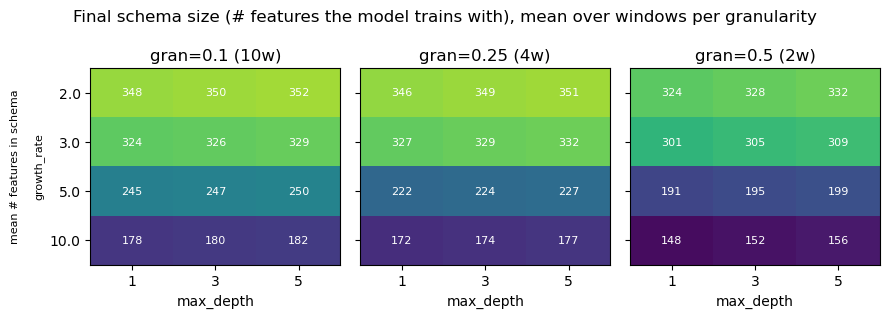

mean   std  min  max
growth_rate max_depth gran                       
2.0         1         0.10  347.7  24.8  298  382
                      0.25  346.0  23.1  319  375
                      0.50  323.5  14.8  313  334
            3         0.10  349.8  24.9  300  384
                      0.25  349.2  23.8  321  378
                      0.50  327.5  13.4  318  337
            5         0.10  352.1  24.9  302  386
                      0.25  351.0  23.3  324  380
                      0.50  331.5  13.4  322  341
3.0         1         0.10  324.3  17.6  294  348
                      0.25  326.8  28.0  290  356
                      0.50  301.0   7.1  296  306
            3         0.10  326.4  17.6  296  350
                      0.25  329.2  28.3  292  359
                      0.50  305.0   5.7  301  309
            5         0.10  328.7  17.4  299  352
                      0.25  331.8  27.8  295  361
                      0.50  309.0   5.7  305  313
5.0         1         0.10  245.3  40.8  183  308
                      0.25  221.8  31.7  182  254
                      0.50  191.0  12.7  182  200
            3         0.10  247.4  40.9  185  310
                      0.25  224.2  31.9  184  257
                      0.50  195.0  14.1  185  205
            5         0.10  249.7  41.0  188  312
                      0.25  226.8  31.4  187  259
                      0.50  199.0  14.1  189  209
10.0        1         0.10  177.7  21.9  139  211
                      0.25  171.8  30.5  139  208
                      0.50  147.5  10.6  140  155
            3         0.10  179.8  21.9  141  213
                      0.25  174.2  30.7  141  211
                      0.50  151.5  12.0  143  160
            5         0.10  182.1  21.6  144  215
                      0.25  176.8  30.2  144  213
                      0.50  155.5  12.0  147  164

In [26]:
fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(3.0 * len(GRANULARITIES), 3.2), sharey=True)
vmin, vmax = grid_df["n_features"].min(), grid_df["n_features"].max()
for col_i, gran in enumerate(GRANULARITIES):
    ax = axes[col_i]
    # Mean across that granularity's windows -- each cell is one (growth_rate,
    # max_depth) config, matching the layout of section 1.1's grid.
    pivot = (
        grid_df[grid_df.gran == gran]
        .groupby(["growth_rate", "max_depth"])["n_features"].mean()
        .unstack("max_depth")
        .reindex(index=GROWTH_RATES, columns=MAX_DEPTHS)
    )
    ax.imshow(pivot.values, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white")
    ax.set_xticks(range(len(MAX_DEPTHS)))
    ax.set_xticklabels(MAX_DEPTHS)
    ax.set_yticks(range(len(GROWTH_RATES)))
    ax.set_yticklabels(GROWTH_RATES)
    n_win = grid_df[grid_df.gran == gran]["win_idx"].nunique()
    ax.set_title(f"gran={gran:g} ({n_win}w)")
    ax.set_xlabel("max_depth")
axes[0].set_ylabel("mean # features in schema\n\ngrowth_rate", fontsize=8)

fig.suptitle("Final schema size (# features the model trains with), mean over windows per granularity")
fig.tight_layout()
savefig(fig, "grid_final_schema_size.png")
plt.show()

final_schema_table = (
    grid_df.groupby(["growth_rate", "max_depth", "gran"])["n_features"]
    .agg(["mean", "std", "min", "max"])
    .round(1)
)
final_schema_table


### 1.7 Feature lifecycle: identity and retention across windows

For each grid point, every mined candidate is reduced to an *identity* that's
comparable across windows at the same granularity, plus the class it leans toward:

- **Level 1 (unfiltered Step 1)** -- every row in `contrast_stats_all.csv`, before any
  selection. There's no pass/fail gate here, so "shows up as attack/benign" is a soft
  proxy: the same growth-rate-direction rule the filter itself uses
  (`growth_rate >= min_growth_rate` -> attack-leaning, `growth_rate <= 1/min_growth_rate`
  -> benign-leaning, from `filter_contrast_survivors`), applied without the coverage
  check. Rows clearing neither direction aren't tracked -- they can never survive
  filtering regardless of coverage, so they're not "a feature" in the sense the later
  levels use.
- **Level 2 (filtered Step 1)** -- `contrast_survivors.csv`, i.e. Level 1 restricted to
  rows that also clear `min_attack_coverage`/`min_benign_coverage`. Comparing 1 vs. 2
  isolates exactly what the coverage threshold prunes, since both share the same
  growth-rate-direction class rule.
- **Level 3 (Step 2 tree)** -- `mined_attribute_features.csv` rows with
  `mining_type == "decision_tree_rule"`. Identity is `base_feature(token)` (threshold
  stripped) rather than the exact itemset, since Step 2's numeric split points shift
  with the data even when the underlying attribute doesn't (same reasoning as section
  1.3); a leaf's `source_label` gives the class directly. A multi-token rule
  contributes one identity per token.

Itemset identity is a `frozenset` of tokens rather than the raw tuple, since pairwise
candidates aren't guaranteed to enumerate in the same token order in every window.

Given identities-by-window per level/class, a feature's "life" is its set of present
windows. Retention at *age* `a` = the fraction of features that first appeared at some
window `w` that are present again at `w + a` -- a standard cohort-retention curve (it
doesn't require the windows in between to be unbroken, so a feature that disappears and
comes back still counts as "retained" at that age). `gran=1.0` has only one window and
is excluded throughout this section.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feature_retention_curves.png


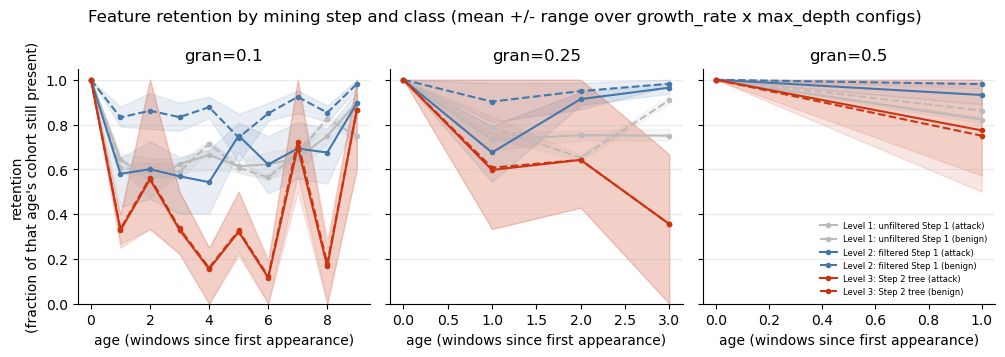

In [27]:
def lifecycle_identity_sets(row: pd.Series) -> dict:
    gr = row["growth_rate"]
    inv_gr = 1.0 / gr

    def _classify(df: pd.DataFrame) -> pd.DataFrame:
        attack_leaning = df["growth_rate"] >= gr
        benign_leaning = (df["confidence_benign"] > 0) & (df["growth_rate"] <= inv_gr)
        out = df[attack_leaning | benign_leaning].copy()
        out["cls"] = np.where(out["growth_rate"] >= gr, "attack", "benign")
        return out

    stats_all = pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv")
    stats_all["itemset"] = stats_all["itemset"].apply(lambda s: frozenset(ast.literal_eval(s)))
    lvl1 = _classify(stats_all)

    survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
    survivors["itemset"] = survivors["itemset"].apply(lambda s: frozenset(ast.literal_eval(s)))
    lvl2 = _classify(survivors)

    feats = pd.read_csv(row["mining_dir"] / "mined_attribute_features.csv")
    tree = feats[feats["mining_type"] == "decision_tree_rule"]
    lvl3_set = frozenset(
        (base_feature(tok), src)
        for itemset_str, src in zip(tree["itemset"], tree["source_label"])
        for tok in ast.literal_eval(itemset_str)
    )

    return {
        "_lvl1_ic": frozenset(zip(lvl1["itemset"], lvl1["cls"])),
        "_lvl2_ic": frozenset(zip(lvl2["itemset"], lvl2["cls"])),
        "_lvl3_ic": lvl3_set,
    }


lifecycle_df = pd.concat(
    [grid_df, grid_df.apply(lifecycle_identity_sets, axis=1).apply(pd.Series)], axis=1
)

LEVELS = [
    ("_lvl1_ic", "Level 1: unfiltered Step 1"),
    ("_lvl2_ic", "Level 2: filtered Step 1"),
    ("_lvl3_ic", "Level 3: Step 2 tree"),
]
CLASSES = ["attack", "benign"]


def retention_curve(window_id_sets: dict[int, frozenset]) -> pd.Series:
    """retention[age] = fraction of identities that first appeared at some window w
    which reappear at w + age (gaps in between are allowed), averaged over every valid
    w for that age -- a standard cohort-retention curve."""
    windows = sorted(window_id_sets)
    first_window: dict = {}
    for w in windows:
        for ident in window_id_sets[w]:
            first_window.setdefault(ident, w)
    max_win = windows[-1]
    out = {}
    for age in range(max_win - windows[0] + 1):
        eligible = [i for i, fw in first_window.items() if fw + age <= max_win]
        if not eligible:
            continue
        present = sum(1 for i in eligible if i in window_id_sets.get(first_window[i] + age, frozenset()))
        out[age] = present / len(eligible)
    return pd.Series(out)


retention_rows, lifecycle_summary_rows = [], []
for (gr, md, gran), sub in lifecycle_df.groupby(["growth_rate", "max_depth", "gran"]):
    if sub["win_idx"].nunique() < 2:
        continue
    sub = sub.sort_values("win_idx")
    last_win = sub["win_idx"].max()
    for col, label in LEVELS:
        for cls in CLASSES:
            window_id_sets = {
                w: frozenset(i for i, c in s if c == cls)
                for w, s in zip(sub["win_idx"], sub[col])
            }
            curve = retention_curve(window_id_sets)
            for age, val in curve.items():
                retention_rows.append({
                    "growth_rate": gr, "max_depth": md, "gran": gran,
                    "level": label, "cls": cls, "age": age, "retention": val,
                })

            first_window: dict = {}
            presence_count: dict = {}
            for w in sorted(window_id_sets):
                for ident in window_id_sets[w]:
                    first_window.setdefault(ident, w)
                    presence_count[ident] = presence_count.get(ident, 0) + 1
            n_ids = len(first_window)
            if n_ids == 0:
                continue
            n_transient = sum(1 for c in presence_count.values() if c == 1)
            from_start = [i for i, fw in first_window.items() if fw == sub["win_idx"].min()]
            n_persistent_from_start = sum(
                1 for i in from_start if i in window_id_sets.get(last_win, frozenset())
            )
            lifecycle_summary_rows.append({
                "growth_rate": gr, "max_depth": md, "gran": gran,
                "level": label, "cls": cls,
                "n_identities": n_ids,
                "mean_windows_present": np.mean(list(presence_count.values())),
                "pct_transient": n_transient / n_ids,
                "pct_persistent_from_start": (
                    n_persistent_from_start / len(from_start) if from_start else np.nan
                ),
            })

retention_df = pd.DataFrame(retention_rows)
lifecycle_summary_df = pd.DataFrame(lifecycle_summary_rows)

LEVEL_COLORS = {
    "Level 1: unfiltered Step 1": NEUTRAL_COLOR,
    "Level 2: filtered Step 1": BENIGN_COLOR,
    "Level 3: Step 2 tree": ATTACK_COLOR,
}
grans_multi = [g for g in GRANULARITIES if lifecycle_df[lifecycle_df.gran == g]["win_idx"].nunique() > 1]

fig, axes = plt.subplots(1, len(grans_multi), figsize=(3.4 * len(grans_multi), 3.6), sharey=True)
for ax, gran in zip(axes, grans_multi):
    sub = retention_df[retention_df.gran == gran]
    for col, label in LEVELS:
        for cls in CLASSES:
            s = sub[(sub.level == label) & (sub.cls == cls)]
            agg = s.groupby("age")["retention"].agg(["mean", "min", "max"])
            ax.plot(
                agg.index, agg["mean"], color=LEVEL_COLORS[label],
                linestyle="-" if cls == "attack" else "--",
                marker="o", markersize=3, linewidth=1.5,
                label=f"{label} ({cls})",
            )
            ax.fill_between(agg.index, agg["min"], agg["max"], color=LEVEL_COLORS[label], alpha=0.12)
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("age (windows since first appearance)")
    ax.set_ylim(0, 1.05)
    strip_axes(ax)
axes[0].set_ylabel("retention\n(fraction of that age's cohort still present)")
axes[-1].legend(frameon=False, fontsize=6, loc="lower right")
fig.suptitle("Feature retention by mining step and class (mean +/- range over growth_rate x max_depth configs)")
fig.tight_layout()
savefig(fig, "grid_feature_retention_curves.png")
plt.show()


### 1.8 Feature presence timeline (Level 2 vs. Level 3)

The retention curves above are an aggregate; this makes it visual for one
representative config (median `growth_rate`, median `max_depth`, `gran=0.1` -- the
finest granularity, most windows to see churn in). Level 1 is left out here: it has
~2,000 unfiltered candidates per window, too many rows to read as a timeline, and its
effect is already visible in the retention curves above -- so this panel is restricted
to identities that survive the contrast filter (Level 2) and the tree leaves built on
top of them (Level 3). Each row is one identity, sorted by the window it first appears
in; a filled cell means present that window, color-coded by class.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feature_swimlane.png


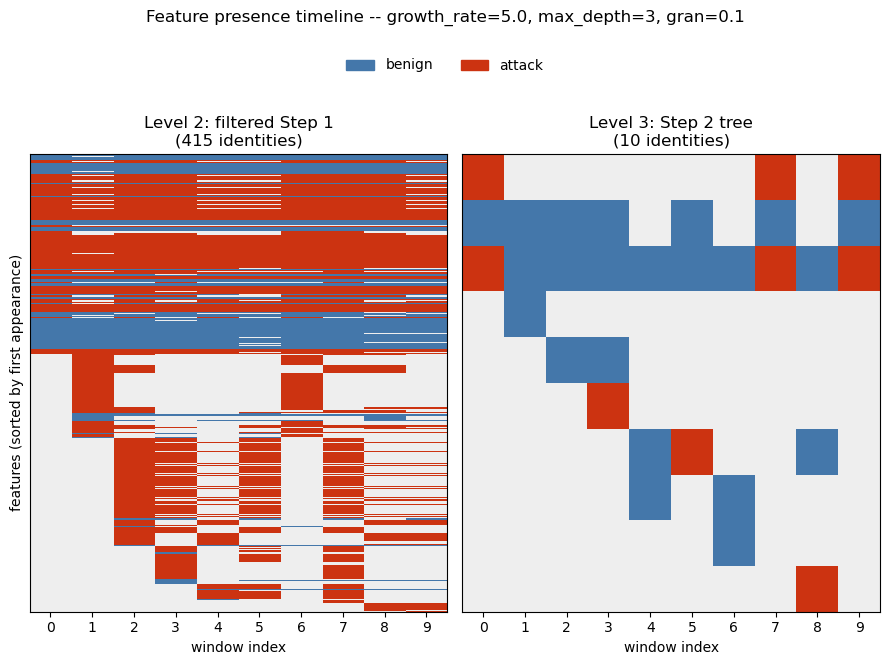

In [28]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

REP_GR, REP_MD, REP_GRAN = GROWTH_RATES[len(GROWTH_RATES) // 2], MAX_DEPTHS[len(MAX_DEPTHS) // 2], 0.1

rep = lifecycle_df[
    (lifecycle_df.growth_rate == REP_GR) & (lifecycle_df.max_depth == REP_MD) & (lifecycle_df.gran == REP_GRAN)
].sort_values("win_idx")
rep_windows = rep["win_idx"].tolist()


def presence_matrix(col: str) -> tuple[np.ndarray, int]:
    sets_by_window = dict(zip(rep_windows, rep[col]))
    first_seen: dict = {}
    cls_by_window: dict = {}
    for w in rep_windows:
        for ident, cls in sets_by_window[w]:
            first_seen.setdefault(ident, w)
            cls_by_window.setdefault(ident, {})[w] = cls
    order = sorted(first_seen, key=lambda i: (first_seen[i], str(i)))
    mat = np.full((len(order), len(rep_windows)), np.nan)
    for r, ident in enumerate(order):
        for c, w in enumerate(rep_windows):
            cls = cls_by_window[ident].get(w)
            if cls is not None:
                mat[r, c] = 1.0 if cls == "attack" else 0.0
    return mat, len(order)


cmap = ListedColormap([BENIGN_COLOR, ATTACK_COLOR])
cmap.set_bad("#EEEEEE")

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
for ax, (col, label) in zip(axes, LEVELS[1:]):
    mat, n_ids = presence_matrix(col)
    ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="none")
    ax.set_title(f"{label}\n({n_ids} identities)")
    ax.set_xlabel("window index")
    ax.set_xticks(range(len(rep_windows)))
    ax.set_yticks([])
    if ax is axes[0]:
        ax.set_ylabel("features (sorted by first appearance)")

fig.legend(
    handles=[Patch(color=BENIGN_COLOR, label="benign"), Patch(color=ATTACK_COLOR, label="attack")],
    loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.04),
)
fig.suptitle(
    f"Feature presence timeline -- growth_rate={REP_GR}, max_depth={REP_MD}, gran={REP_GRAN:g}",
    y=1.1,
)
fig.tight_layout()
savefig(fig, "grid_feature_swimlane.png")
plt.show()


### 1.9 Lifecycle summary table

Per `(level, class, gran)`, averaged over `growth_rate x max_depth` configs:
`n_identities` (distinct features ever seen), `mean_windows_present` (average number of
windows a feature is alive for, out of however many that granularity has),
`pct_transient` (appears in exactly one window, never again), and
`pct_persistent_from_start` (present in the first window *and* still present in the
last, regardless of what happens in between).

In [29]:
lifecycle_table = (
    lifecycle_summary_df.groupby(["level", "cls", "gran"])[
        ["n_identities", "mean_windows_present", "pct_transient", "pct_persistent_from_start"]
    ]
    .mean()
    .round(3)
)
lifecycle_table


n_identities  mean_windows_present  pct_transient  pct_persistent_from_start
level                      cls    gran                                                                              
Level 1: unfiltered Step 1 attack 0.10       867.250                 5.761          0.237                      0.898
                                  0.25       828.750                 2.865          0.256                      0.750
                                  0.50       809.000                 1.715          0.285                      0.822
                           benign 0.10       324.000                 6.343          0.082                      0.749
                                  0.25       277.250                 3.087          0.155                      0.908
                                  0.50       245.750                 1.805          0.195                      0.862
Level 2: filtered Step 1   attack 0.10       306.250                 6.073          0.054                      0.896
                                  0.25       262.500                 2.737          0.359                      0.965
                                  0.50       172.250                 1.844          0.156                      0.932
                           benign 0.10        98.500                 8.323          0.030                      0.982
                                  0.25        87.500                 3.690          0.041                      0.982
                                  0.50        80.750                 1.934          0.066                      0.980
Level 3: Step 2 tree       attack 0.10        10.000                 3.066          0.460                      0.867
                                  0.25         7.167                 1.935          0.550                      0.356
                                  0.50         6.333                 1.597          0.403                      0.774
                           benign 0.10         9.333                 3.144          0.444                      0.867
                                  0.25         6.833                 1.960          0.538                      0.356
                                  0.50         6.333                 1.567          0.433                      0.750

### 1.10 Does `class_weight` / `min_samples_leaf` move the mined schema's structure?

Neither has ever been varied anywhere in this codebase's mining pipeline before
-- `screening_mining_settings.yaml` and (until now) this sweep only ever
varied `min_growth_rate x max_depth`, leaving every other
`AttributeMiningConfig` field at its schema default. `sweep_attribute_schema.sh`'s
second grid block adds `class_weight in {balanced, none}` and
`min_samples_leaf in {10, 20, 40}`, one axis at a time, with `growth_rate`
held fixed (see that script's module docstring, and
`notebooks/inspect_cscas_dataset.ipynb` section 17 for the data-level
reasoning behind which value it's fixed at).

This is a **structural** comparison only -- same six metrics section 1.1
already computes (`n_step1_candidates`, `n_contrast`, `n_tree_leaves`,
`mean_tree_confidence_attack`, `mean_rule_length`, `top2_feature_share`), not
model precision/recall/FPR. `config_selection.ipynb` is where that empirical
evidence comes from, once these axes are added to
`screening_mining_settings.yaml` and a real screening-sweep run trains and
evaluates models against them.

Degrades gracefully below if the new sweep points haven't been mined yet.

In [30]:
STRUCTURAL_METRICS = [
    ("n_step1_candidates", "# Step 1 candidates"),
    ("n_contrast", "# Step 1 survivors"),
    ("n_tree_leaves", "# Step 2 leaves"),
    ("mean_tree_confidence_attack", "mean leaf confidence_attack"),
    ("mean_rule_length", "mean rule length"),
    ("top2_feature_share", "top-2 feature share"),
]

# growth_rate values where class_weight/min_samples_leaf actually vary --
# dynamic rather than hardcoding MIN_GROWTH_RATE_FIXED from the shell script,
# so this cell works regardless of which value that script was run with.
axis_variation = grid_df_all.groupby("growth_rate", dropna=False)[["class_weight", "min_samples_leaf"]].nunique()
growth_rates_with_new_axis = axis_variation[
    (axis_variation["class_weight"] > 1) | (axis_variation["min_samples_leaf"] > 1)
].index.tolist()

HAS_NEW_AXIS_DATA = bool(growth_rates_with_new_axis)
if HAS_NEW_AXIS_DATA:
    axis_df = grid_df_all[grid_df_all["growth_rate"].isin(growth_rates_with_new_axis)].copy()
    # class_weight="none" round-trips through config.yaml as Python None (YAML
    # null), not the string "none" -- groupby drops NaN/None groups by default,
    # so give it an explicit label instead of relying on dropna=False everywhere.
    axis_df["class_weight_label"] = axis_df["class_weight"].fillna("none").astype(str)
    print(
        f"{len(axis_df)} runs found at growth_rate={growth_rates_with_new_axis}: "
        f"class_weight={sorted(axis_df['class_weight_label'].unique())}, "
        f"min_samples_leaf={sorted(axis_df['min_samples_leaf'].unique())}"
    )
else:
    axis_df = None
    print(
        "No class_weight/min_samples_leaf sweep points found under artifacts/mining/ yet.\n"
        "Run the extended src/thesis/shell-scripts/sweep_attribute_schema.sh "
        "(its second grid block) first, then re-run this section."
    )

432 runs found at growth_rate=[3.0]: class_weight=['balanced'], min_samples_leaf=[5, 10, 20]


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_class_weight_min_samples_leaf_effect.png


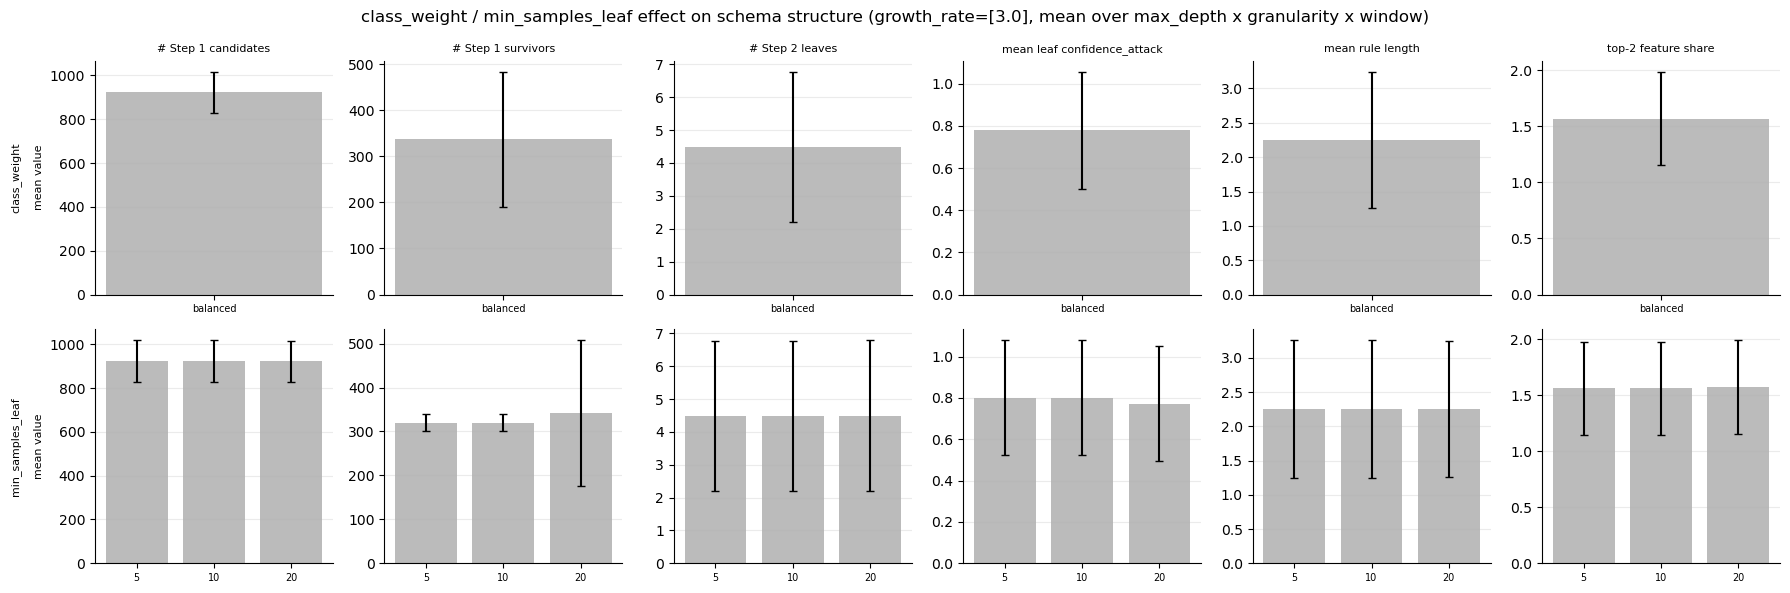

In [31]:
if HAS_NEW_AXIS_DATA:
    fig, axes = plt.subplots(2, len(STRUCTURAL_METRICS), figsize=(3.0 * len(STRUCTURAL_METRICS), 6.0))
    for col_i, (metric, label) in enumerate(STRUCTURAL_METRICS):
        ax = axes[0, col_i]
        cw_stats = axis_df.groupby("class_weight_label")[metric].agg(["mean", "std"])
        ax.bar(cw_stats.index, cw_stats["mean"], yerr=cw_stats["std"].fillna(0), color=NEUTRAL_COLOR, capsize=3)
        ax.set_title(label, fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        if col_i == 0:
            ax.set_ylabel("class_weight\n\nmean value", fontsize=8)
        strip_axes(ax)

        ax = axes[1, col_i]
        msl_stats = axis_df.groupby("min_samples_leaf")[metric].agg(["mean", "std"])
        ax.bar(msl_stats.index.astype(str), msl_stats["mean"], yerr=msl_stats["std"].fillna(0), color=NEUTRAL_COLOR, capsize=3)
        ax.tick_params(axis="x", labelsize=7)
        if col_i == 0:
            ax.set_ylabel("min_samples_leaf\n\nmean value", fontsize=8)
        strip_axes(ax)

    fig.suptitle(
        f"class_weight / min_samples_leaf effect on schema structure "
        f"(growth_rate={growth_rates_with_new_axis}, mean over max_depth x granularity x window)"
    )
    fig.tight_layout()
    savefig(fig, "grid_class_weight_min_samples_leaf_effect.png")
    plt.show()

**eta² read**: `thesis.metrics.sensitivity.parameter_importance` (built for
`config_selection.ipynb`'s model-precision importance table, section 9 there
-- generic over any `param_cols`/`score_col`, so it applies here unchanged)
run against each of the six structural metrics in turn, with
`param_cols=["max_depth", "gran", "class_weight_label", "min_samples_leaf"]`.
Puts `class_weight`/`min_samples_leaf` on the same eta²/Cohen's-convention
scale `max_depth`/`granularity` were already shown to score highly on in
section 1.1's heatmaps -- if either new axis comes back negligible here too
(the same way `min_growth_rate` did on model precision), that's the
structural-level evidence for leaving it out of the real
`screening_mining_settings.yaml` sweep entirely, rather than paying for a
third/fourth axis in the expensive empirical run.

In [32]:
if HAS_NEW_AXIS_DATA:
    from IPython.display import display

    from thesis.metrics.sensitivity import effect_size_label, parameter_importance

    importance_rows = []
    for metric, _ in STRUCTURAL_METRICS:
        imp = parameter_importance(
            axis_df,
            score_col=metric,
            param_cols=["max_depth", "gran", "class_weight_label", "min_samples_leaf"],
        )
        imp.insert(0, "outcome_metric", metric)
        importance_rows.append(imp)

    structure_importance = pd.concat(importance_rows, ignore_index=True)
    structure_importance["effect_size"] = structure_importance["eta_squared"].apply(effect_size_label)
    structure_importance = structure_importance.sort_values(
        ["outcome_metric", "eta_squared"], ascending=[True, False]
    ).reset_index(drop=True)
    # Nested inside `if` -- a bare trailing expression here wouldn't
    # auto-display the way it does at cell top-level, so display() explicitly.
    display(structure_importance)

,outcome_metric,parameter,n_levels,n_configs,eta_squared,f_stat,p_value,effect_range,effect_size
0,mean_rule_length,max_depth,3,432,0.974095,8.065657e+03,0.000000e+00,2.385427,large
1,mean_rule_length,gran,3,432,0.006167,1.331048e+00,2.652891e-01,0.236685,negligible
2,mean_rule_length,min_samples_leaf,3,432,0.000001,2.650186e-04,9.997350e-01,0.002648,negligible
3,mean_rule_length,class_weight_label,1,432,NaN,NaN,NaN,NaN,n/a
4,mean_tree_confidence_attack,max_depth,3,432,0.547346,2.593716e+02,1.451898e-74,0.495560,large
5,mean_tree_confidence_attack,gran,3,432,0.121846,2.976235e+01,7.869153e-13,0.294995,medium
6,mean_tree_confidence_attack,min_samples_leaf,3,432,0.001814,3.897588e-01,6.774597e-01,0.028524,negligible
7,mean_tree_confidence_attack,class_weight_label,1,432,NaN,NaN,NaN,NaN,n/a
8,n_contrast,min_samples_leaf,3,432,0.003876,8.346900e-01,4.347126e-01,21.901786,negligible
9,n_contrast,gran,3,432,0.002093,4.499163e-01,6.379820e-01,15.027778,negligible


### 1.11 Does `min_attack_coverage` / `min_benign_coverage` move the mined schema's structure?

`sweep_attribute_schema.py`'s third grid varies `min_attack_coverage` and
`min_benign_coverage` one axis at a time (holding the other at its 0.05
default: `COVERAGE_GRID_NEW`), anchored at the same
`growth_rate=MIN_GROWTH_RATE_FIXED` as section 1.10's class_weight/
min_samples_leaf grid.

Same structural-only comparison as section 1.10 (the same six
`STRUCTURAL_METRICS`, not model precision/recall/FPR -- see that section's
markdown for why), restricted here to `class_weight="balanced"` and
`min_samples_leaf=20` (grid 1's defaults) so section 1.10's own axis
variation, which shares this growth_rate, doesn't leak into this one.

Degrades gracefully below if the coverage sweep points haven't been mined yet.


In [33]:
axis_variation_cov = (
    grid_df_all[
        (grid_df_all["class_weight"] == "balanced") & (grid_df_all["min_samples_leaf"] == 20)
    ]
    .groupby("growth_rate", dropna=False)[["min_attack_coverage", "min_benign_coverage"]]
    .nunique()
)
growth_rates_with_coverage_axis = axis_variation_cov[
    (axis_variation_cov["min_attack_coverage"] > 1) | (axis_variation_cov["min_benign_coverage"] > 1)
].index.tolist()

HAS_COVERAGE_AXIS_DATA = bool(growth_rates_with_coverage_axis)
if HAS_COVERAGE_AXIS_DATA:
    # class_weight/min_samples_leaf pinned to grid 1's defaults -- see the
    # markdown above -- so this is grid 1 (the 0.05/0.05 anchor) plus grid 3
    # only, not grid 2's class_weight/min_samples_leaf variation.
    coverage_df = grid_df_all[
        (grid_df_all["growth_rate"].isin(growth_rates_with_coverage_axis))
        & (grid_df_all["class_weight"] == "balanced")
        & (grid_df_all["min_samples_leaf"] == 20)
    ].copy()
    print(
        f"{len(coverage_df)} runs found at growth_rate={growth_rates_with_coverage_axis}: "
        f"min_attack_coverage={sorted(coverage_df['min_attack_coverage'].unique())}, "
        f"min_benign_coverage={sorted(coverage_df['min_benign_coverage'].unique())}"
    )
else:
    coverage_df = None
    print(
        "No min_attack_coverage/min_benign_coverage sweep points found under artifacts/mining/ yet.\n"
        "Run src/thesis/scripts/mining/sweep_attribute_schema.py (grid 3) first, then re-run this section."
    )


336 runs found at growth_rate=[3.0]: min_attack_coverage=[0.0, 0.05, 0.15, 0.3], min_benign_coverage=[0.0, 0.05, 0.15, 0.3]


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_coverage_effect.png


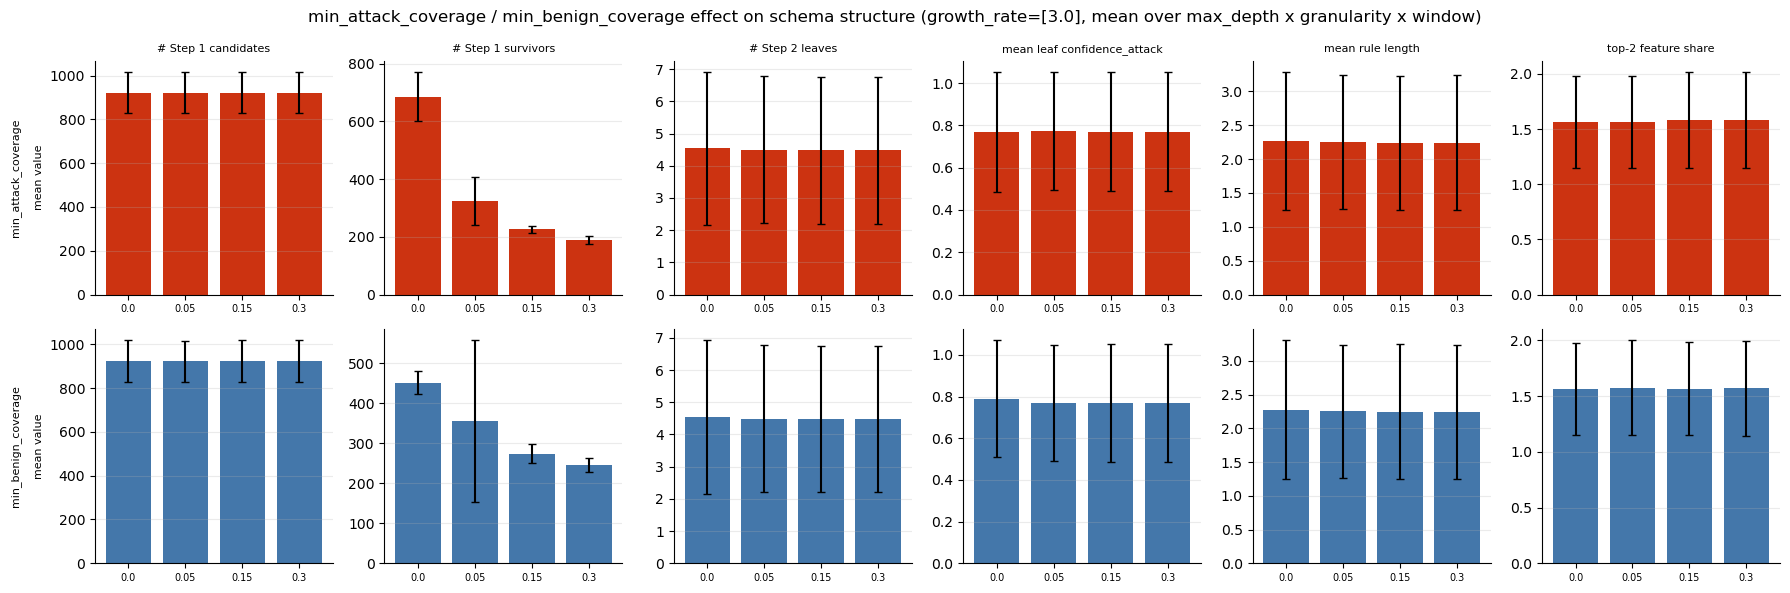

In [34]:
if HAS_COVERAGE_AXIS_DATA:
    fig, axes = plt.subplots(2, len(STRUCTURAL_METRICS), figsize=(3.0 * len(STRUCTURAL_METRICS), 6.0))
    for col_i, (metric, label) in enumerate(STRUCTURAL_METRICS):
        ax = axes[0, col_i]
        ac_stats = coverage_df.groupby("min_attack_coverage")[metric].agg(["mean", "std"])
        ax.bar(ac_stats.index.astype(str), ac_stats["mean"], yerr=ac_stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
        ax.set_title(label, fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        if col_i == 0:
            ax.set_ylabel("min_attack_coverage\n\nmean value", fontsize=8)
        strip_axes(ax)

        ax = axes[1, col_i]
        bc_stats = coverage_df.groupby("min_benign_coverage")[metric].agg(["mean", "std"])
        ax.bar(bc_stats.index.astype(str), bc_stats["mean"], yerr=bc_stats["std"].fillna(0), color=BENIGN_COLOR, capsize=3)
        ax.tick_params(axis="x", labelsize=7)
        if col_i == 0:
            ax.set_ylabel("min_benign_coverage\n\nmean value", fontsize=8)
        strip_axes(ax)

    fig.suptitle(
        f"min_attack_coverage / min_benign_coverage effect on schema structure "
        f"(growth_rate={growth_rates_with_coverage_axis}, mean over max_depth x granularity x window)"
    )
    fig.tight_layout()
    savefig(fig, "grid_coverage_effect.png")
    plt.show()


**eta² read**: same `parameter_importance` helper as section 1.10
(`thesis.metrics.sensitivity.parameter_importance`), run against each of the
six structural metrics with
`param_cols=["max_depth", "gran", "min_attack_coverage", "min_benign_coverage"]`.
If either coverage threshold comes back negligible here, that's
structural-level evidence for leaving it out of a real
`screening_mining_settings.yaml` sweep -- same reasoning section 1.10 applies
to `class_weight`/`min_samples_leaf`.


In [35]:
if HAS_COVERAGE_AXIS_DATA:
    from IPython.display import display

    from thesis.metrics.sensitivity import effect_size_label, parameter_importance

    coverage_importance_rows = []
    for metric, _ in STRUCTURAL_METRICS:
        imp = parameter_importance(
            coverage_df,
            score_col=metric,
            param_cols=["max_depth", "gran", "min_attack_coverage", "min_benign_coverage"],
        )
        imp.insert(0, "outcome_metric", metric)
        coverage_importance_rows.append(imp)

    coverage_importance = pd.concat(coverage_importance_rows, ignore_index=True)
    coverage_importance["effect_size"] = coverage_importance["eta_squared"].apply(effect_size_label)
    coverage_importance = coverage_importance.sort_values(
        ["outcome_metric", "eta_squared"], ascending=[True, False]
    ).reset_index(drop=True)
    display(coverage_importance)


,outcome_metric,parameter,n_levels,n_configs,eta_squared,f_stat,p_value,effect_range,effect_size
0,mean_rule_length,max_depth,3,336,0.973559,6.130641e+03,2.032810e-263,2.384228,large
1,mean_rule_length,gran,3,336,0.006166,1.032942e+00,3.570959e-01,0.236468,negligible
2,mean_rule_length,min_benign_coverage,4,336,0.000095,1.046770e-02,9.985306e-01,0.032370,negligible
3,mean_rule_length,min_attack_coverage,4,336,0.000075,8.317311e-03,9.989573e-01,0.028849,negligible
4,mean_tree_confidence_attack,max_depth,3,336,0.590560,2.401528e+02,2.689802e-65,0.514575,large
5,mean_tree_confidence_attack,gran,3,336,0.110453,2.067401e+01,3.440235e-09,0.283880,medium
6,mean_tree_confidence_attack,min_benign_coverage,4,336,0.000701,7.767762e-02,9.720423e-01,0.021262,negligible
7,mean_tree_confidence_attack,min_attack_coverage,4,336,0.000109,1.206557e-02,9.981843e-01,0.006949,negligible
8,n_contrast,min_attack_coverage,4,336,0.818136,4.978457e+02,1.730876e-122,496.437500,large
9,n_contrast,min_benign_coverage,4,336,0.139965,1.801033e+01,7.480321e-11,206.000000,medium
